In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys

In [3]:
sys.argv = ['-f'] + ["MIC", "-a", "cpu", "--testunklar"]

In [4]:
import os
sys.path.append("/home/pwiesenbach/BertGCN")
os.chdir("/home/pwiesenbach/BertGCN")

In [5]:
from entry import * 

In [6]:
import importlib
import entry
import logging
importlib.reload(logging)
importlib.reload(entry)

<module 'entry' from '/beegfs/homes/pwiesenbach/BertGCN/entry.py'>

In [7]:
from utils import *
import json 
import pandas as pd
import random
from pathlib import Path
import pickle
from transformers import AutoTokenizer
from torch.utils.data import Subset
import re
from collections import Counter

random.seed(0)

In [8]:
MODELNAME = Path(PRETRAINEDMODEL).stem
if args.data == "MIC":
    DATASET = "med_indication_all_RF_diag"
    if args.testunklar:
        DATASETPATH =  Path("data") / f"ind.{DATASET}_{args.doclevel}_testunklar"
    else:
        DATASETPATH =  Path("data") / f"ind.{DATASET}_{args.doclevel}"
elif args.data == "CSC":
    DATASET = "CARDIODE400_main"
    DATASETPATH =  Path("data") / f"ind.{DATASET}"


adj, features, y_train, y_val, y_test, train_mask, val_mask, test_mask, _, _ = load_corpus(DATASETPATH)
doc_mask = train_mask + val_mask + test_mask
adj.sum()


nb_node = features.shape[0]
nb_train, nb_val, nb_test = train_mask.sum(), val_mask.sum(), test_mask.sum()
nb_word = nb_node - nb_train - nb_val - nb_test
nb_class = y_train.shape[1]

y = y_train + y_val + y_test
y_train = y_train.argmax(axis=1)
y = y.argmax(axis=1)

tokenizer = AutoTokenizer.from_pretrained(PRETRAINEDMODEL)

if args.data == "MIC":
    dataset_file = Path("data") / f"medindcls_{args.bertmodel}_{args.doclevel}.json"
    if not dataset_file.exists():
        print("Creating dataset")
        dataset = CleanClinicDataset(tokenizer=tokenizer, task="MIC", doclevel=args.doclevel, clean=False)
        with open(dataset_file, "wb") as f:
            print(f"Saving dataset under {dataset_file}")
            pickle.dump(dataset, f)
    else:
        print(f"Loading dataset from: {dataset_file}")
        with open(dataset_file, "rb") as f:
            dataset = pickle.load(f)

if args.data == "MIC":
    if not args.testunklar:
        idx = np.arange(len(dataset))
        random.shuffle(idx)
        train_idx, val_idx, test_idx = (
            idx[: int(len(idx) * 0.7)],
            idx[int(len(idx) * 0.7) : int(len(idx) * 0.8)],
            idx[int(len(idx) * 0.8) :],
        )
        train_dataset = Subset(dataset, train_idx)
        val_dataset = Subset(dataset, val_idx)
        test_dataset = Subset(dataset, test_idx)
    else:
        _train_idx, test_idx = list(), list()
        for i, x in enumerate(dataset):
            if "unklar" in dataset.LE.classes_[x["labels"]]:
                test_idx.append(i)
            else:
                _train_idx.append(i)
        test_dataset = Subset(dataset, test_idx)
        random.shuffle(_train_idx)
        train_idx, val_idx = (
            _train_idx[: int(len(_train_idx) * 0.9)],
            _train_idx[int(len(_train_idx) * 0.9) :],
        )
        train_dataset = Subset(dataset, train_idx)
        val_dataset = Subset(dataset, val_idx)
        assert len(train_idx) + len(val_idx) == len(_train_idx)

Loading dataset from: data/medindcls_medbert_letter.json


In [9]:
GCNNAME = f"{MODELNAME}_{dataset}.pt"
if args.testunklar:
    GCNNAME = f"{MODELNAME}_{dataset}_testunklar.pt"

SAVEDIR = Path(f"models/gcn/{args.mixfactor}/{args.doclevel}")
GCNPATH= SAVEDIR / GCNNAME

IGFILE = SAVEDIR / f"ig_attrs_gcn_{MODELNAME}_{args.data}.npz"
SHAPFILE = SAVEDIR / f"shap_values_gcn_{MODELNAME}_{args.data}.npz"
if args.testunklar:
    IGFILE = SAVEDIR / f"ig_attrs_gcn_{MODELNAME}_{args.data}_testunklar.npz"
    SHAPFILE = SAVEDIR / f"shap_values_gcn_{MODELNAME}_{args.data}_testunklar.npz"
IGFILE

PosixPath('models/gcn/0.5/letter/ig_attrs_gcn_med_bert_local_MIC_testunklar.npz')

In [10]:
ig_gcn_bert_values = np.load(IGFILE, "rb")['arr_0']
shap_gcn_bert_values = np.load(SHAPFILE, "rb")['arr_0']

In [11]:
train_len = len(train_idx)
val_len = len(val_idx)
test_len = len(test_idx)

def map_to_idx(x):
    if x < train_len:
        return train_idx[x]
    elif x < val_len + train_len:
        return val_idx[x - train_len]
    else:
        return test_idx[x - val_len - train_len]

In [40]:
top_n_interpret = 5
top_ig_gcn_bert_values = np.argpartition(ig_gcn_bert_values, -top_n_interpret)[:, -top_n_interpret:]
top_ig_gcn_bert_values = np.vectorize(map_to_idx)(top_ig_gcn_bert_values)
top_shap_gcn_bert_values = np.argpartition(shap_gcn_bert_values, -top_n_interpret)[:, -top_n_interpret:]
top_shap_gcn_bert_values = np.vectorize(map_to_idx)(top_shap_gcn_bert_values)

In [13]:
first_order_adj = adj @ adj
first_order_adj = first_order_adj.toarray()

In [14]:
top_n_input = 10
top_input_test_rel_nodes = np.argpartition(first_order_adj[test_mask][:, doc_mask], -top_n_input)[:, -top_n_input:]
top_input_test_rel_nodes = np.vectorize(map_to_idx)(top_input_test_rel_nodes)
top_input_test_rel_nodes.shape

(125, 10)

In [41]:
s = 0
for a, b in zip(top_input_test_rel_nodes, top_ig_gcn_bert_values):
    s += len(np.intersect1d(a, b))
print(s)

s = 0
for a, b in zip(top_input_test_rel_nodes, top_shap_gcn_bert_values):
    s += len(np.intersect1d(a, b))
print(s)

87
88


In [16]:
top_input_test_rel_nodes.shape, top_ig_gcn_bert_values.shape

((125, 10), (125, 3))

In [42]:
input_only, interpret_only, both = list(), list(), list()
for a, b in zip(top_input_test_rel_nodes, top_ig_gcn_bert_values):
    input_only.append(np.setdiff1d(a, b))
    interpret_only.append(np.setdiff1d(b, a))
    both.append(np.intersect1d(b, a))
compare_df = pd.DataFrame({"interpret only": interpret_only, "input only": input_only, "both": both}, index=test_idx)
compare_df

,interpret only,input only,both
16,"[239, 2151, 2152]","[12, 13, 14, 15, 107, 2420, 2421, 2422]","[16, 17]"
17,"[239, 2151, 2152]","[12, 13, 14, 15, 108, 2420, 2421, 2422]","[16, 17]"
35,"[1829, 1830, 1831, 1834, 1837]","[35, 36, 37, 38, 39, 1545, 1546, 1548, 1549, 1...",[]
37,"[1829, 1830, 1831, 1834, 1837]","[35, 36, 37, 38, 39, 1545, 1546, 1548, 1549, 1...",[]
38,"[1829, 1830, 1831, 1834, 1837]","[35, 36, 37, 38, 39, 1544, 1545, 1547, 1548, 1...",[]
...,...,...,...
2607,"[290, 808, 1876, 1877]","[36, 37, 38, 39, 2602, 2603, 2604, 2605, 2606]",[2607]
2632,"[2341, 2342, 2343, 2344, 2350]","[1249, 1250, 1251, 1252, 2632, 2633, 2634, 263...",[]
2633,"[2341, 2342, 2343, 2344, 2350]","[1249, 1250, 1251, 1252, 2632, 2633, 2634, 263...",[]
2634,"[2341, 2342, 2343, 2344, 2350]","[1249, 1250, 1251, 1252, 2632, 2633, 2634, 263...",[]


In [43]:
compare_df["data label"] = [dataset.LE.classes_[dataset[x]["labels"]] for x in compare_df.index]

<AxesSubplot:>

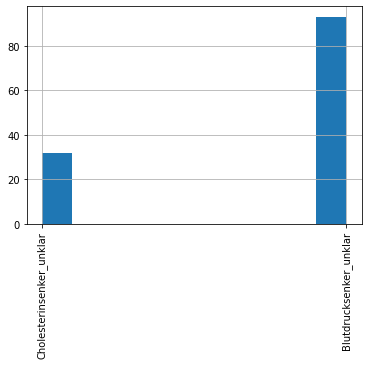

In [44]:
compare_df["data label"].hist(xrot=90)

In [20]:
from model import BertGCN
from ignite.engine import Engine, Events
from ignite.utils import setup_logger
import dgl
import datetime
import torch.utils.data as Data
from ignite.metrics import Accuracy, ClassificationReport, Loss, Precision, Recall
from ignite.handlers.stores import EpochOutputStore
from metrics import SklearnClassificationReport

BATCHSIZE = 8

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model = BertGCN(
    nb_class=nb_class,
    pretrained_model=PRETRAINEDMODEL,
    mix_factor=args.mixfactor,
    gcn_layers=2,
    n_hidden=200,
    dropout=0.5,
)

model = model.to(device)
model = model.eval()

# document mask used for update feature
doc_mask = train_mask + val_mask + test_mask

input_ids = torch.cat(
    [
        torch.tensor(np.array([x["input_ids"] for x in np.array(dataset.examples)[train_idx]])),
        torch.zeros((nb_word, tokenizer.model_max_length), dtype=torch.long),
        torch.tensor(np.array([x["input_ids"] for x in np.array(dataset.examples)[val_idx]])),
        torch.tensor(np.array([x["input_ids"] for x in np.array(dataset.examples)[test_idx]])),
    ]
)

assert np.array_equal(y[:nb_train], dataset.labels[train_idx])
assert np.array_equal(y[nb_train + nb_word : nb_train + nb_word + nb_val], dataset.labels[val_idx])

assert np.array_equal(y[-nb_test:], dataset.labels[test_idx])

adj_norm = normalize_adj(adj + sp.eye(adj.shape[0]))


test_idx_dataset = Data.TensorDataset(torch.arange(nb_node - nb_test, nb_node, dtype=torch.long))

idx_loader_test = Data.DataLoader(test_idx_dataset, batch_size=BATCHSIZE)

graph = dgl.from_scipy(adj_norm.astype("float32"), eweight_name="edge_weight")
graph.ndata["input_ids"] = input_ids
graph.ndata["label"], graph.ndata["train"], graph.ndata["val"], graph.ndata["test"] = (
    torch.LongTensor(y),
    torch.FloatTensor(train_mask),
    torch.FloatTensor(val_mask),
    torch.FloatTensor(test_mask),
)
graph.ndata["label_train"] = torch.LongTensor(y_train)
graph.ndata["cls_feats"] = torch.zeros((nb_node, model.feat_dim))

def update_feature():
    global graph, model
    dataloader = Data.DataLoader(Data.TensorDataset(graph.ndata["input_ids"][doc_mask]), batch_size=64)
    with torch.no_grad():
        model.eval()
        cls_list = []
        logging.info("Udating features...")
        for batch in dataloader:
            input_ids = [x.to(device) for x in batch][0]
            output = model.bert_model(input_ids=input_ids)[0][:, 0]
            cls_list.append(output.cpu())
        cls_feat = torch.cat(cls_list, axis=0)
    graph = graph.to("cpu")
    graph.ndata["cls_feats"][doc_mask] = cls_feat
    
logging.info(f"Loading best gcn model from {GCNPATH} saved on {datetime.datetime.fromtimestamp(GCNPATH.stat().st_ctime)}")
model.load_state_dict(torch.load(GCNPATH, map_location="cpu"))

update_feature()

def eval_step(engine, batch):
    global model, graph
    with torch.no_grad():
        model.eval()
        model = model.to(device)
        graph = graph.to(device)
        (idx,) = [x.to(device) for x in batch]
        y_pred = model(graph, idx)
        y_true = graph.ndata["label"][idx]
        return y_pred, y_true

test_evaluator = Engine(eval_step)
test_evaluator.logger = setup_logger("test evaluator", level=30)

precision = Precision(average=False)
recall = Recall(average=False)
F1 = (precision * recall * 2 / (precision + recall)).mean()
criterion = torch.nn.CrossEntropyLoss()

metrics = {
    "accuracy": Accuracy(),
    "f1": F1,
    "nll": Loss(criterion),
    "cr": SklearnClassificationReport(target_names=dataset.LE.classes_),
    "eos": EpochOutputStore()
}

for n, f in metrics.items():
    f.attach(test_evaluator, n)
    
test_evaluator.run(idx_loader_test)
metrics = test_evaluator.state.metrics

preds = np.vectorize(lambda x: dataset.LE.classes_[x])(np.concatenate([np.argmax(x[0].cpu().numpy(), axis=-1) for x in test_evaluator.state.eos]).ravel()).tolist()

Using backend: pytorch
Some weights of BertModel were not initialized from the model checkpoint at /prj/doctoral_letters/PETGUI/med_bert_local and are newly initialized: ['bert.pooler.dense.weight', 'bert.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [45]:
compare_df["prediction"] = preds
compare_df["data label"] = [dataset.LE.classes_[dataset[x]["labels"]] for x in compare_df.index]
compare_df["correct pred"] = list(map(int, compare_df["prediction"] == compare_df["data label"]))
compare_df["arznei"] = [re.findall("Arznei (.+?) &", dataset.texts[x])[0] for x in compare_df.index]
compare_df["interpret labels"] = [dataset.LE.classes_[[dataset[y]["labels"] for y in x]] for x in compare_df["interpret only"]]
compare_df["interpret arznei"] = [[re.findall("Arznei (.+?) &", dataset.texts[y])[0] for y in x] for x in compare_df["interpret only"]]
compare_df["input labels"] = [dataset.LE.classes_[[dataset[y]["labels"] for y in x]] for x in compare_df["input only"]]
compare_df["input arznei"] = [[re.findall("Arznei (.+?) &", dataset.texts[y])[0] for y in x] for x in compare_df["input only"]]
compare_df["label overlap"] = [sum([xx in y for xx in x])/3 for x, y in zip(compare_df["interpret labels"], compare_df["input labels"])]
compare_df["arznei overlap"] = [sum([xx in y for xx in x])/3 for x, y in zip(compare_df["interpret arznei"], compare_df["input arznei"])]
compare_df["interpret label equals data label"] = [sum([xx==y for xx in x])/3 for x, y in zip(compare_df["interpret labels"], compare_df["data label"])]
compare_df["interpret arznei equals data arznei"] = [sum([xx==y for xx in x])/3 for x, y in zip(compare_df["interpret arznei"], compare_df["arznei"])]
compare_df.describe()

,correct pred,label overlap,arznei overlap,interpret label equals data label,interpret arznei equals data arznei
count,125.0,125.000000,125.000000,125.000000,125.000000
mean,0.0,0.368000,0.370667,0.117333,0.080000
std,0.0,0.575522,0.357250,0.291012,0.171437
min,0.0,0.000000,0.000000,0.000000,0.000000
25%,0.0,0.000000,0.000000,0.000000,0.000000
50%,0.0,0.000000,0.333333,0.000000,0.000000
75%,0.0,0.666667,0.666667,0.000000,0.000000
max,0.0,1.666667,1.333333,1.333333,0.666667


In [22]:
if not os.path.exists("outputs/csvs/"):
    os.mkdir("outputs/csvs/")
compare_df.to_csv("outputs/csvs/compare_df_testunklar.csv")

In [46]:
diff_df = compare_df[compare_df['interpret only'].map(len) == top_n_interpret]

In [47]:
diff_df.describe()

,correct pred,label overlap,arznei overlap,interpret label equals data label,interpret arznei equals data arznei
count,87.0,87.000000,87.000000,87.0,87.000000
mean,0.0,0.459770,0.444444,0.0,0.065134
std,0.0,0.620996,0.361831,0.0,0.167356
min,0.0,0.000000,0.000000,0.0,0.000000
25%,0.0,0.000000,0.000000,0.0,0.000000
50%,0.0,0.000000,0.333333,0.0,0.000000
75%,0.0,1.166667,0.666667,0.0,0.000000
max,0.0,1.666667,1.333333,0.0,0.666667


<AxesSubplot:>

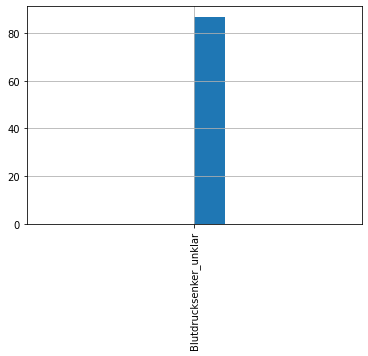

In [48]:
diff_df["data label"].hist(xrot=90)

<AxesSubplot:>

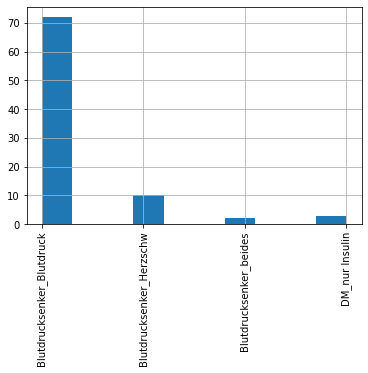

In [49]:
diff_df["prediction"].hist(xrot=90)

In [52]:
random.seed(0)
n_letters_per = 3

sample_df = diff_df.groupby('data label', as_index=True).apply(lambda s: s.sample(min(len(s), 3 * n_letters_per)))
sample_df.index = sample_df.index.droplevel()
sample_df.index

Int64Index([1357, 1863, 1783, 1866, 1620, 553, 37, 1594, 2573], dtype='int64')

In [53]:
letter_dir = "outputs/letters"   
#letter_dir = "outputs/letters/testunklar/"   

if not os.path.exists(letter_dir):
    os.mkdir(letter_dir)

c = 0
for i, x in enumerate(sample_df.index):
    if i % n_letters_per == 0:
        c += 1
        
    path = f"{letter_dir}/{c}"
    
    if not os.path.exists(path):
        os.mkdir(path)
        
    letter_path = f"{path}/{x}"
    
    if not os.path.exists(letter_path):
        os.mkdir(letter_path)
    
    with open(f"{letter_path}/{sample_df.loc[x]['data label']}-{sample_df.loc[x]['prediction']}.txt", 'w') as f:
        print(dataset.texts[x], file=f)
    prev = None
    for y in sample_df.loc[x]["interpret only"]:
        ass_path = f"{letter_path}/{y}"

        arznei = re.findall("Arznei (.+?) &", dataset.texts[y])[0]
        cur = dataset.texts[y]
        start = re.search("Arznei .+? &", cur).span()[1]
        if prev is None or prev != cur[start:]:
            if not os.path.exists(ass_path):
                os.mkdir(ass_path)      
        
            with open(f"{ass_path}/{dataset.LE.classes_[dataset[y]['labels']]}.txt", 'w') as f:
                print(cur[start:].strip(), file=f)
        prev = cur[start:]